In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader
import torchvision
from torchvision.models.detection.image_list import ImageList

Testing for have available GPU for train?

In [7]:
torch.cuda.is_available()

True

Setting the train core on Gpu else on cpu.

In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
DEVICE

device(type='cuda')

In [18]:
IMAGE_DIR = '/mnt/d/Computer-Vision/R-CNN/dataset/dataset/images'
ANNOTATIONS_DIR = "/mnt/d/Computer-Vision/R-CNN/dataset/dataset/annotations"
TARGET_SIZE = (224, 224)
BATCH_SIZE = 8

In [19]:
class_names = [d for d in os.listdir(IMAGE_DIR) if os.path.isdir(os.path.join(IMAGE_DIR, d))]

In [20]:
class_names

['airplane', 'face', 'motorcycle']

In [21]:
csv_files = [f for f in os.listdir(ANNOTATIONS_DIR) if f.endswith('.csv')]

In [22]:
csv_files

['airplane.csv', 'face.csv', 'motorcycle.csv']

In [23]:
label_map = {name: i + 1 for i, name in enumerate(class_names)}

In [24]:
label_map

{'airplane': 1, 'face': 2, 'motorcycle': 3}

In [25]:
dataset = []

for i in range(len(class_names)):
    class_name = class_names[i]
    class_dir = os.path.join(IMAGE_DIR, class_name)
    csv_file_name = csv_files[i]
    
    csv_path = os.path.join(ANNOTATIONS_DIR, csv_file_name)
    df_annotations = pd.read_csv(csv_path)

    for image_name in os.listdir(class_dir):
        image_path = os.path.join(class_dir, image_name)
        
        image = cv2.imread(image_path)
        h, w, _ = image.shape

        ann = df_annotations[df_annotations['image_name'] == image_name].iloc[0,1:].tolist()
        
        ann[0] = (ann[0] / w) * 224
        ann[1] = (ann[1] / h) * 224
        ann[2] = (ann[2] / w) * 224
        ann[3] = (ann[3] / h) * 224

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        # permute(2, 0, 1) >>> changing the (w,h,c) to (c,w,h)
        image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        label_tensor = torch.tensor([class_names.index(class_name)], dtype=torch.int64)
        ann_tensor = torch.tensor([ann], dtype=torch.float32)  # shape = [1, 4]

        target = {
            'boxes': ann_tensor,
            'labels': label_tensor
        }
        dataset.append((image_tensor, target))

def collate_fn(batch):
    return tuple(zip(*batch))

dataloader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)

In [26]:
resnet_model = torchvision.models.resnet18()

In [27]:
from torchsummary import summary

In [31]:
resnet_model = resnet_model.to(DEVICE)

In [32]:
summary(resnet_model,(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

Deleting last 2 layers because we dont need them.

In [37]:
backbone = torch.nn.Sequential(*list(resnet_model.children())[:-2])
backbone.out_channels = 512 # custom attribute

In [38]:
backbone.out_channels

512

In [39]:
summary(backbone,(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [40]:
for param in backbone.parameters():
    param.requires_grad = False

In [41]:
from torchvision.models.detection.rpn import RPNHead, RegionProposalNetwork, AnchorGenerator

In [42]:
# Anchor
anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

In [43]:
in_channels = backbone.out_channels
num_anchors = anchor_generator.num_anchors_per_location()[0]

rpn_head = RPNHead(in_channels=in_channels, num_anchors=num_anchors)

In [44]:
rpn_model = RegionProposalNetwork(
    anchor_generator,
    rpn_head,
    fg_iou_thresh=0.7,
    bg_iou_thresh=0.3,
    batch_size_per_image=256,
    positive_fraction=0.5,
    pre_nms_top_n={'training': 2000, 'testing': 1000},
    post_nms_top_n={'training': 1000, 'testing': 500},
    nms_thresh=0.7
)

In [47]:
rpn_model

RegionProposalNetwork(
  (anchor_generator): AnchorGenerator()
  (head): RPNHead(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
      )
    )
    (cls_logits): Conv2d(512, 9, kernel_size=(1, 1), stride=(1, 1))
    (bbox_pred): Conv2d(512, 36, kernel_size=(1, 1), stride=(1, 1))
  )
)

In [48]:
optimizer = torch.optim.Adam(rpn_model.parameters(), lr=0.001)

Model Training.

In [49]:
backbone.to(DEVICE)
rpn_model.to(DEVICE)
backbone.eval()
rpn_model.train()

NUM_EPOCHS = 5
for epoch in range(NUM_EPOCHS):
    epoch_losses = []
    
    for images, targets in dataloader:
        optimizer.zero_grad()
        
        images_gpu = torch.stack([img.to(DEVICE) for img in images]) # stack: [batch_size, channels, height, width]
        targets_gpu = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        
        with torch.no_grad():
            features = backbone(images_gpu)
        
        image_list = ImageList(images_gpu, [img.shape[-2:] for img in images])
        
        _, loss_dict = rpn_model(image_list, {'0': features}, targets_gpu)
        loss = loss_dict['loss_objectness'] + loss_dict['loss_rpn_box_reg']
        
        if torch.isfinite(loss):
            epoch_losses.append(loss.item())
            loss.backward()
            optimizer.step()
    
    if epoch_losses:
        mean_loss = sum(epoch_losses) / len(epoch_losses)
        print(f"Epoch {epoch+1} | Loss: {mean_loss:.4f}")
    else:
        print(f"Epoch {epoch+1} | No valid losses")

Epoch 1 | Loss: 0.0180
Epoch 2 | Loss: 0.0031
Epoch 3 | Loss: 0.0018
Epoch 4 | Loss: 0.0014
Epoch 5 | Loss: 0.0012


In [50]:
def visualize_rpn_proposals(image_path, rpn_model_trained, backbone_model_trained):
    TARGET_SIZE = (224,224)
    rpn_model_trained.to(DEVICE)
    backbone_model_trained.to(DEVICE)
    rpn_model_trained.eval()
    backbone_model_trained.eval()

    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    
    image_rgb_resized = cv2.resize(img_rgb, TARGET_SIZE)
    img_tensor = (torch.tensor(image_rgb_resized, dtype=torch.float32).permute(2, 0, 1) / 255.0).to(DEVICE)

    with torch.no_grad():
        features = backbone_model_trained(img_tensor.unsqueeze(0))
        
        image_list = ImageList(img_tensor.unsqueeze(0), [tuple(img_tensor.shape[-2:])])
        
        proposals, _ = rpn_model_trained(image_list, {'0': features})


    top_proposals = proposals[0][:5].cpu().numpy()
    
    print(f"\nTotal proposals (after NMS): {len(proposals[0])}")
    print("Drawing top 5 proposals on the image...")
    
    for i, box in enumerate(top_proposals):
        x1, y1, x2, y2 = map(int, box)
        
        # Color coding based on proposal rank
        if i == 0:
            color_rgb, width = (0, 255, 0), 3   # Green for the best
        elif i < 3:
            color_rgb, width = (255, 255, 0), 2 # Yellow for good
        else:
            color_rgb, width = (255, 0, 0), 1   # Red for the rest
        
        img_display = cv2.rectangle(image_rgb_resized, (x1, y1), (x2, y2), color=color_rgb, thickness=width)

    plt.figure(figsize=(8, 8))
    plt.imshow(img_display)
    plt.axis('off') 
    plt.show()



Total proposals (after NMS): 286
Drawing top 5 proposals on the image...


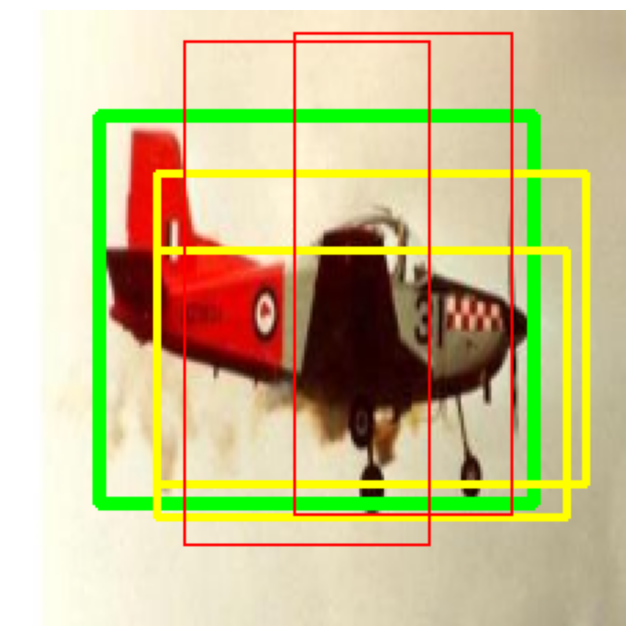

In [54]:
TEST_IMAGE_PATH = '/mnt/d/Computer-Vision/R-CNN/dataset/dataset/images/airplane/image_0002.jpg'
visualize_rpn_proposals(TEST_IMAGE_PATH, rpn_model, backbone)